# 05. Cohort Retention Analysis

**Question:** After someone visits the platform for the first time, do they come back?

Users are grouped by the month they first showed up. We then track what percentage of each group was still active 1, 2, 3, 4, and 5 months later.

Only groups with at least 6 months of data are included — newer users simply haven't had enough time yet, so mixing them in would make the numbers look worse than they actually are.

In [1]:
from src.db import run_sql
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "DejaVu Sans"

In [2]:
df = run_sql("../sql/analysis_cohorts.sql")
df['cohort_month']   = pd.to_datetime(df['cohort_month'])
df['activity_month'] = pd.to_datetime(df['activity_month'])

# Cohort sizes (M+0 users per cohort)
cohort_sizes = (
    df[df['cohort_index'] == 0]
    .groupby('cohort_month')['user_id'].nunique()
    .reset_index().rename(columns={'user_id': 'cohort_size'})
)

# Per-cohort per-month active users
activity = (
    df.groupby(['cohort_month', 'cohort_index'])['user_id']
    .nunique().reset_index().rename(columns={'user_id': 'active_users'})
)
activity = activity.merge(cohort_sizes, on='cohort_month')
activity['retention'] = (activity['active_users'] / activity['cohort_size'] * 100).round(1)

# Keep only cohorts with full 6-month window (M+0 through M+5)
has_m5 = activity[activity['cohort_index'] == 5]['cohort_month'].unique()
act6 = activity[
    activity['cohort_month'].isin(has_m5) &
    (activity['cohort_index'] <= 5)
].copy()
sizes6 = cohort_sizes[cohort_sizes['cohort_month'].isin(has_m5)].copy()
sizes6['label'] = sizes6['cohort_month'].dt.strftime('%Y-%m')

print(f"Total users in dataset:          {df['user_id'].nunique():,}")
print(f"Cohorts with full 6-month data:  {len(has_m5)} (out of {cohort_sizes.shape[0]})")
print(f"Date range covered:              {sizes6['label'].iloc[0]} → {sizes6['label'].iloc[-1]}")
print(f"Users in valid cohorts:          {sizes6['cohort_size'].sum():,}")

Total users in dataset:          9,995
Cohorts with full 6-month data:  17 (out of 22)
Date range covered:              2024-01 → 2025-05
Users in valid cohorts:          9,977


## 1. How Many New Users Joined Each Month

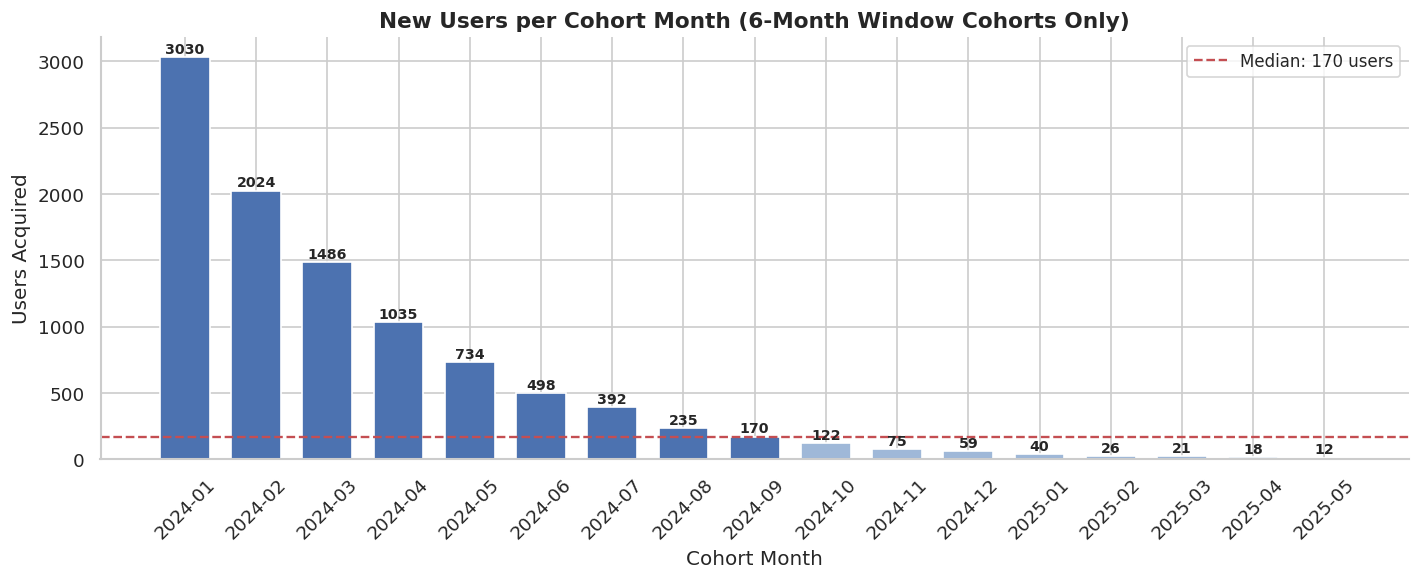

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#4C72B0' if s >= sizes6['cohort_size'].median() else '#9FB8D8'
          for s in sizes6['cohort_size']]
bars = ax.bar(sizes6['label'], sizes6['cohort_size'], color=colors, edgecolor='white', width=0.7)
for bar, val in zip(bars, sizes6['cohort_size']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+8,
            str(val), ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax.axhline(sizes6['cohort_size'].median(), color='#C44E52', linewidth=1.4,
           linestyle='--', label=f"Median: {int(sizes6['cohort_size'].median())} users")
ax.set_title("New Users per Cohort Month (6-Month Window Cohorts Only)", fontsize=13, fontweight='bold')
ax.set_xlabel("Cohort Month")
ax.set_ylabel("Users Acquired")
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

**Observation:** January 2024 had 3,030 new users — almost 3 times more than any other month. After that, the numbers dropped steadily every month. By early 2025, fewer than 50 new users were joining per month. There's no recovery visible in the data.

## 2. Did Users Come Back After Their First Month?

Each row = a group of users who first showed up in that month.  
Each column = how many of them were still active 1, 2, 3, 4, or 5 months later.  

Example: the row `2024-01` shows 100% → 29% → 32% → 31% → 30% → 31%.  
This means: all 3,030 users were active in January, then 29% came back in February, 32% in March, and so on.

Green = more users returned. Red = fewer users returned.

Retention matrix (%):
                M+0   M+1   M+2   M+3   M+4   M+5
cohort_month                                     
2024-01       100.0  29.0  32.2  30.8  30.2  30.5
2024-02       100.0  28.9  28.7  30.3  30.0  29.7
2024-03       100.0  28.3  33.6  26.9  32.2  30.4
2024-04       100.0  28.3  27.9  31.0  32.3  27.8
2024-05       100.0  30.9  30.7  27.8  29.0  28.7
2024-06       100.0  30.5  32.3  33.9  28.1  29.5
2024-07       100.0  30.6  33.2  29.8  28.3  30.1
2024-08       100.0  27.7  28.9  31.5  29.4  29.4
2024-09       100.0  35.3  35.3  32.9  30.0  28.2
2024-10       100.0  30.3  30.3  27.9  31.1  33.6
2024-11       100.0  29.3  29.3  36.0  40.0  29.3
2024-12       100.0  27.1  30.5  23.7  33.9  25.4
2025-01       100.0  25.0  17.5  25.0  20.0  30.0
2025-02       100.0  34.6  11.5  42.3  42.3  42.3
2025-03       100.0  23.8  38.1  42.9  19.0  42.9
2025-04       100.0  22.2  22.2  44.4  38.9  33.3
2025-05       100.0   8.3  16.7   8.3  16.7  25.0


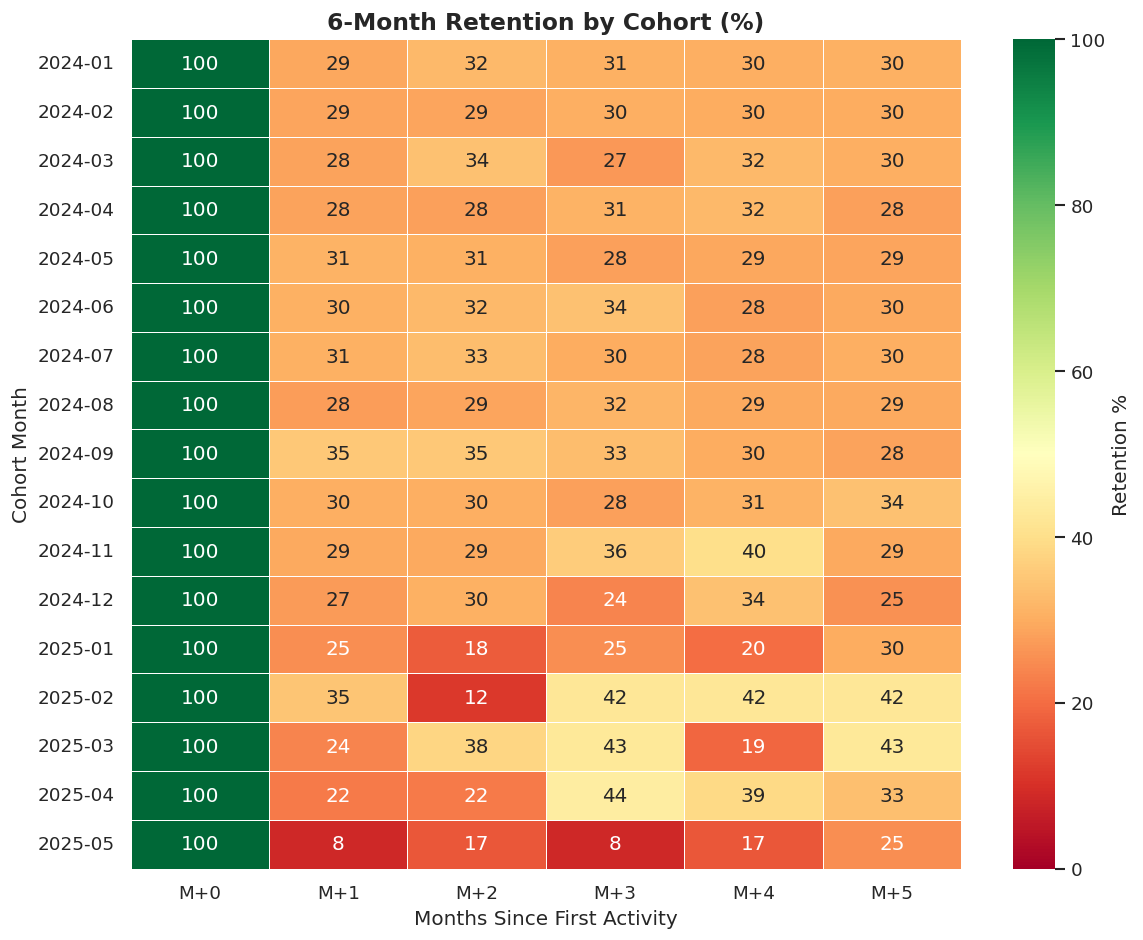

In [4]:
retention_matrix = act6.pivot(
    index='cohort_month', columns='cohort_index', values='retention'
)
retention_matrix.index = retention_matrix.index.strftime('%Y-%m')
retention_matrix.columns = [f"M+{int(c)}" for c in retention_matrix.columns]

print("Retention matrix (%):")
print(retention_matrix.to_string())

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    retention_matrix,
    annot=True, fmt='.0f', linewidths=0.5,
    cmap='RdYlGn',
    vmin=0, vmax=100,
    cbar_kws={'label': 'Retention %'},
    ax=ax
)
ax.set_title("6-Month Retention by Cohort (%)", fontsize=14, fontweight='bold')
ax.set_xlabel("Months Since First Activity")
ax.set_ylabel("Cohort Month")
plt.tight_layout()
plt.show()

**Observation:** Every single group loses about 70% of users after the first month — no exceptions across 17 months of data. January 2024 went from 100% down to 29%. February went from 100% down to 29%. The same drop happens every month. After that, the numbers stop falling — users who come back in month 2 stay active through month 6 at roughly the same rate (28–34%).

## 3. The Average Return Rate Over 6 Months

Average % of users still active:
  Joined              100.0%
  1 month later       27.7%
  2 months later      28.2%
  3 months later      30.9%
  4 months later      30.1%
  5 months later      30.9%

Drop from month 1 to month 2: 72% of users stopped returning


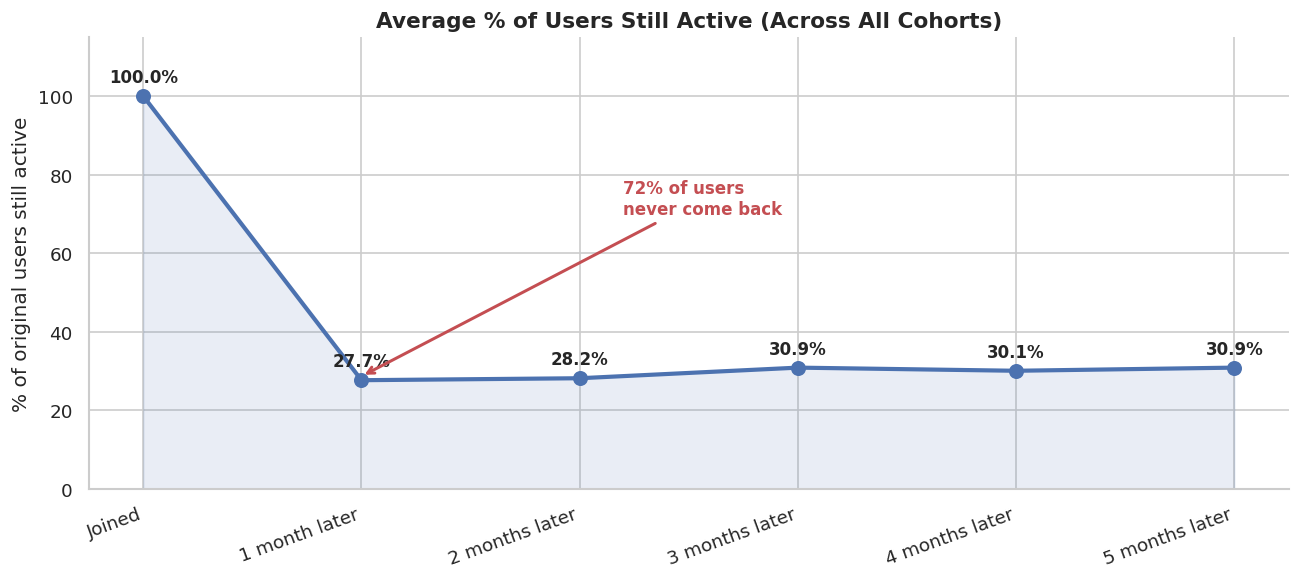

In [5]:
avg_ret = act6.groupby('cohort_index')['retention'].mean().round(1).reset_index()
avg_ret.columns = ['month_number', 'avg_pct']
avg_ret['label'] = ['Joined', '1 month later', '2 months later',
                    '3 months later', '4 months later', '5 months later']

m0 = avg_ret.loc[0, 'avg_pct']
m1 = avg_ret.loc[1, 'avg_pct']

print("Average % of users still active:")
for _, row in avg_ret.iterrows():
    print(f"  {row['label']:<18}  {row['avg_pct']:.1f}%")
print(f"\nDrop from month 1 to month 2: {m0-m1:.0f}% of users stopped returning")

fig, ax = plt.subplots(figsize=(11, 5))
x = range(len(avg_ret))
ax.plot(x, avg_ret['avg_pct'], color='#4C72B0', linewidth=2.5, marker='o', markersize=8, zorder=3)
ax.fill_between(x, avg_ret['avg_pct'], alpha=0.12, color='#4C72B0')
for i, row in avg_ret.iterrows():
    ax.text(i, row['avg_pct'] + 3.5, f"{row['avg_pct']:.1f}%",
            ha='center', fontsize=10, fontweight='bold')
ax.annotate(
    f"{m0-m1:.0f}% of users\nnever come back",
    xy=(1, m1+1), xytext=(2.2, 70),
    fontsize=10, color='#C44E52', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#C44E52', lw=1.8)
)
ax.set_xticks(x)
ax.set_xticklabels(avg_ret['label'], rotation=20, ha='right')
ax.set_title("Average % of Users Still Active (Across All Cohorts)", fontsize=13, fontweight='bold')
ax.set_ylabel("% of original users still active")
ax.set_ylim(0, 115)
sns.despine()
plt.tight_layout()
plt.show()

**Observation:** On average, 71% of users leave after month one and never return. The remaining 29% barely change over the next 5 months — their return rate stays between 29% and 33%. The chart shows one sharp drop, then a flat line. The problem isn't that users slowly drift away — it's that most of them leave immediately.

## 4. How Much Do Active Users Actually Do Each Month?

 month  avg_events
   0.0        1.19
   1.0        1.19
   2.0        1.20
   3.0        1.19
   4.0        1.20
   5.0        1.18


/var/folders/3g/2__y7fts5pzdtr01xrq6gl5m0000gn/T/ipykernel_28699/2157042097.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g['events_count'].sum() / g['user_id'].nunique())


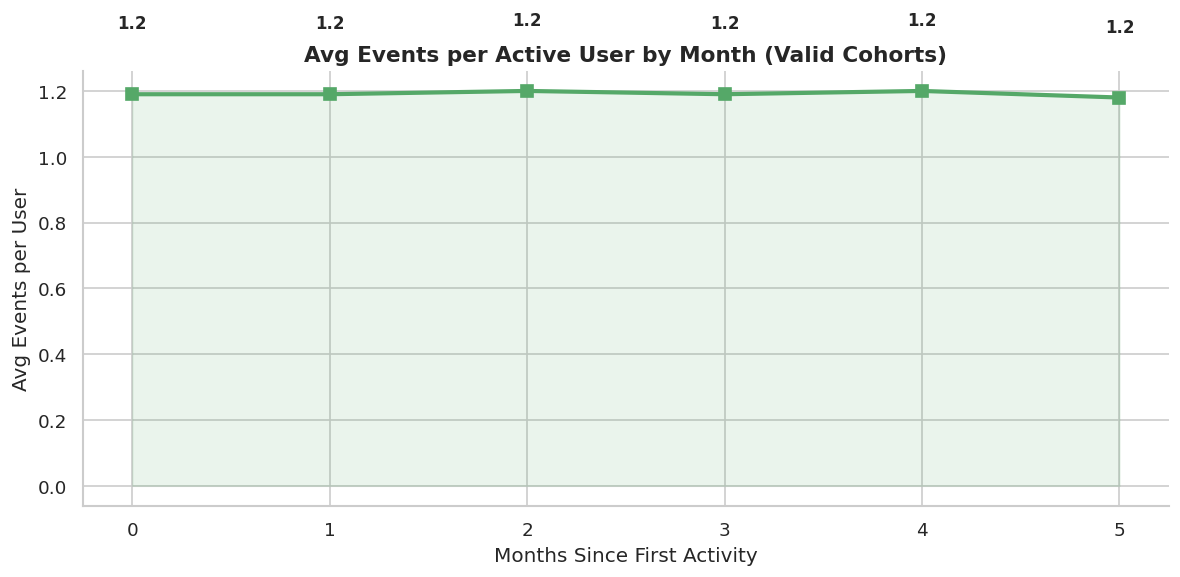

In [6]:
eng = (
    df[df['cohort_month'].isin(has_m5) & (df['cohort_index'] <= 5)]
    .groupby('cohort_index')
    .apply(lambda g: g['events_count'].sum() / g['user_id'].nunique())
    .round(2).reset_index()
)
eng.columns = ['month', 'avg_events']

print(eng.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(eng['month'], eng['avg_events'],
        color='#55A868', linewidth=2.5, marker='s', markersize=7, zorder=3)
ax.fill_between(eng['month'], eng['avg_events'], alpha=0.12, color='#55A868')
for _, row in eng.iterrows():
    ax.text(row['month'], row['avg_events']+0.2,
            f"{row['avg_events']:.1f}", ha='center', fontsize=10, fontweight='bold')
ax.set_title("Avg Events per Active User by Month (Valid Cohorts)", fontsize=13, fontweight='bold')
ax.set_xlabel("Months Since First Activity")
ax.set_ylabel("Avg Events per User")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
sns.despine()
plt.tight_layout()
plt.show()

**Observation:** Users who stay active do roughly the same number of things on the platform each month. The line is almost flat from month 1 through month 6. They're not becoming more engaged over time, but they're not becoming less engaged either — they've settled into a stable routine from early on.

## 5. Does the Drop-off Look the Same for Every Month's Group?

If users who joined in one particular month came back at a much higher rate, it could point to something specific that worked — a promotion, a product update, a seasonal effect. This chart checks whether any group stands out.

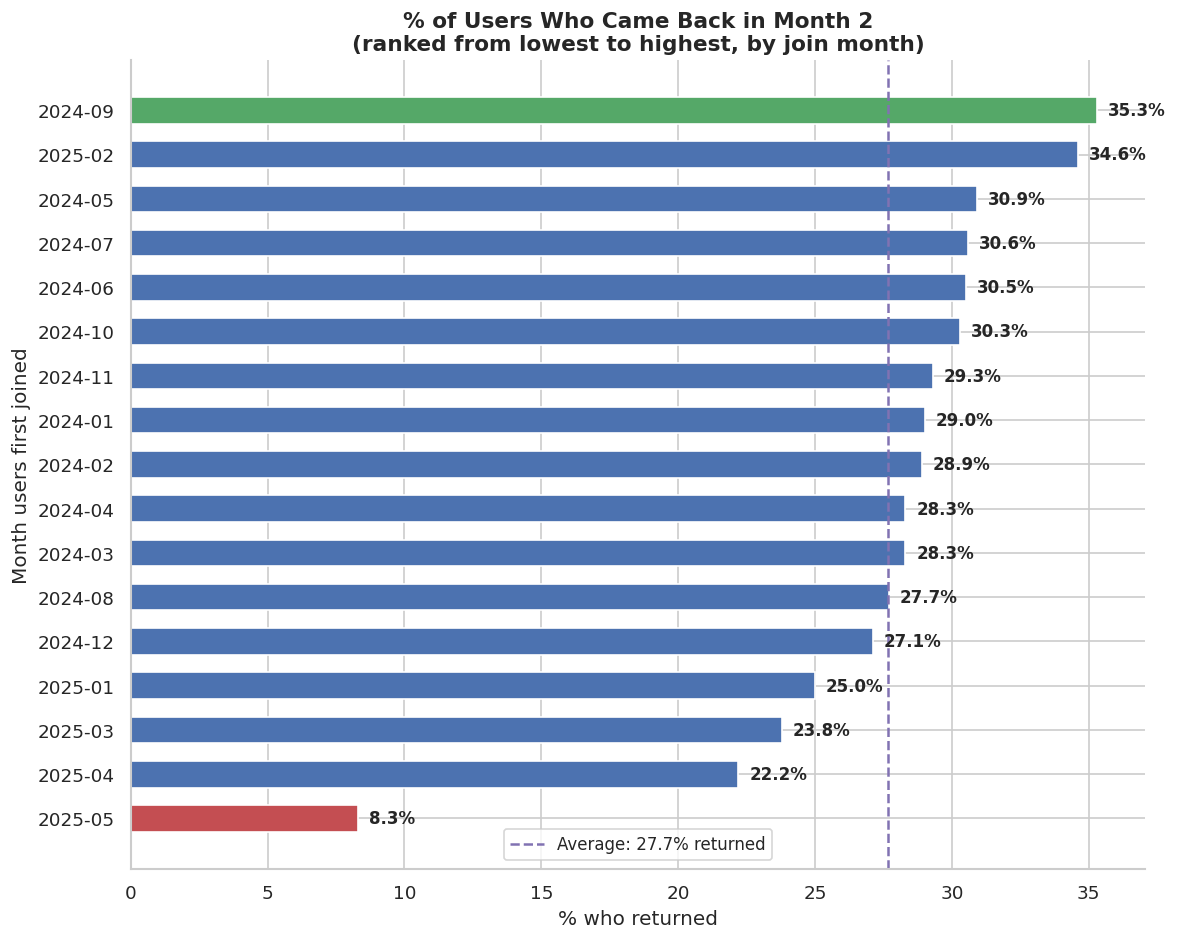

Best:    2024-09  — 35.3% came back  (60 out of 170 users)
Worst:   2025-05  — 8.3% came back  (1 out of 12 users)
Average across all groups: 27.7%


In [7]:
m1_ret = act6[act6['cohort_index']==1][['cohort_month','retention','active_users','cohort_size']].copy()
m1_ret['label'] = m1_ret['cohort_month'].dt.strftime('%Y-%m')
m1_ret = m1_ret.sort_values('retention', ascending=True)
avg_m1 = m1_ret['retention'].mean()

colors = ['#C44E52' if v == m1_ret['retention'].min() else
          '#55A868' if v == m1_ret['retention'].max() else '#4C72B0'
          for v in m1_ret['retention']]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(m1_ret['label'], m1_ret['retention'], color=colors, edgecolor='white', height=0.6)
for bar, val in zip(bars, m1_ret['retention']):
    ax.text(bar.get_width()+0.4, bar.get_y()+bar.get_height()/2,
            f"{val:.1f}%", va='center', fontsize=10, fontweight='bold')
ax.axvline(avg_m1, color='#8172B2', linewidth=1.5, linestyle='--',
           label=f"Average: {avg_m1:.1f}% returned")
ax.set_title("% of Users Who Came Back in Month 2\n(ranked from lowest to highest, by join month)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("% who returned")
ax.set_ylabel("Month users first joined")
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

best  = m1_ret.iloc[-1]
worst = m1_ret.iloc[0]
print(f"Best:    {best['label']}  — {best['retention']:.1f}% came back  ({int(best['active_users'])} out of {int(best['cohort_size'])} users)")
print(f"Worst:   {worst['label']}  — {worst['retention']:.1f}% came back  ({int(worst['active_users'])} out of {int(worst['cohort_size'])} users)")
print(f"Average across all groups: {avg_m1:.1f}%")

**Observation:** The average return rate across all groups is 27.7%. The best month was September 2024 — 35.3% came back (60 out of 170 users). The worst is May 2025 at 8.3%, but that group only had 12 users total, meaning 1 person came back — that number isn't reliable. If we look at the larger cohorts (100+ users), they all sit between 27% and 35%, which is a narrow range. No group with a meaningful sample size stands out as dramatically better or worse.

---

## Key Findings

**7 out of 10 users visit once and never come back.** This holds true for every single month from January 2024 through mid-2025. It's the most consistent pattern in the data.

**Users who return once tend to stay for months.** The 29% who come back in the second month keep returning through month 3, 4, 5, and 6 at almost the same rate. There's no slow drop-off — it's either they stay or they don't.

**No single month performed significantly better.** Every group of users, regardless of when they joined, had nearly the same second-month return rate. This rules out a specific campaign, broken feature, or seasonal dip as the cause.

**New user acquisition is collapsing.** January 2024 brought 3,030 new users. By early 2025 it was under 50 per month. With 71% leaving after month one, adding more new users won't help until the first-visit experience improves.

**The biggest opportunity is the gap between visit one and visit two.** The platform already knows how to keep users once they return — it just needs to figure out how to get them back that first time.